In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os

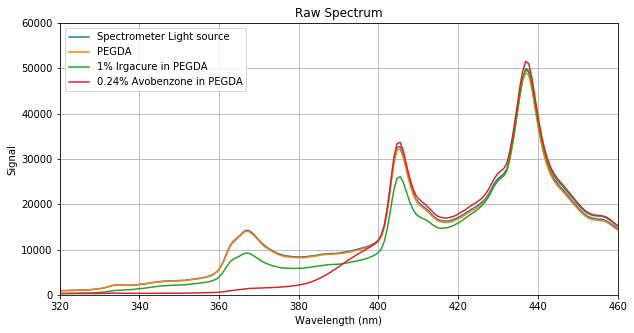

In [2]:
os.chdir('C:/Users/Mawla/Desktop/Winter 2020/Lab Stuff_Winter 2020/Paper Plan/200120_old_spectrometer')
os.getcwd()
os.listdir()

# Light source:
light_source = np.loadtxt('QEPB00791_17-07-21-669.txt', skiprows = 14)
light_source_wavelength = light_source[:, 0]
light_source_signal = light_source[:, 1]

# PEGDA:
#os.chdir('C:/Users/Mawla/Desktop/Winter 2020/Lab Stuff_Winter 2020/Paper Plan/200116_old_spectrometer/200116_PEGDA')
#os.getcwd()
#os.listdir()

PEGDA = np.loadtxt('QEPB00791_17-10-07-458.txt', skiprows = 14)
PEGDA_wavelength = PEGDA[:, 0]
PEGDA_signal = PEGDA[:, 1]

# 1% IRGA in PEGDA:
#os.chdir('C:/Users/Mawla/Desktop/Winter 2020/Lab Stuff_Winter 2020/Paper Plan/200116_old_spectrometer/200116_PEGDA_IRGA')
#os.getcwd()
#os.listdir()

IRGA_PEGDA = np.loadtxt('QEPB00791_17-13-57-708.txt', skiprows = 14)
IRGA_PEGDA_wavelength = IRGA_PEGDA[:, 0]
IRGA_PEGDA_signal = IRGA_PEGDA[:, 1]

# 0.24% Avobenzone in PEGDA:
#os.chdir('C:/Users/Mawla/Desktop/Winter 2020/Lab Stuff_Winter 2020/Paper Plan/200116_old_spectrometer/200116_Avobenzone')
#os.getcwd()
#os.listdir()

Avobenzone = np.loadtxt('QEPB00791_17-18-57-140.txt', skiprows = 14)
Avobenzone_wavelength = Avobenzone[:, 0]
Avobenzone_signal = Avobenzone[:, 1]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(light_source_wavelength, light_source_signal, label = 'Spectrometer Light source')
ax.plot(PEGDA_wavelength, PEGDA_signal, label = 'PEGDA')
ax.plot(IRGA_PEGDA_wavelength, IRGA_PEGDA_signal, label = '1% Irgacure in PEGDA')
ax.plot(Avobenzone_wavelength, Avobenzone_signal, label = '0.24% Avobenzone in PEGDA')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Signal')
ax.set_title("Raw Spectrum")
ax.set_xlim([320, 460])
ax.set_ylim([0, 60000])
ax.legend()
ax.grid()
os.chdir('C:/Users/Mawla/Desktop/Winter 2020/Lab Stuff_Winter 2020/Paper Plan/200120_old_spectrometer/200120_Fig')
plt.savefig("Raw Spectrum_200120.png")



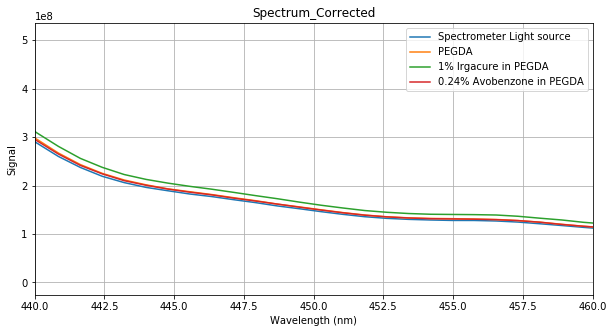

In [4]:
P_source = 130.66e-6
P_pegda = 125.10e-6
P_irga = 123.85e-6
P_avobenzone = 133.92e-6

light_source_signal_corrected = light_source_signal/P_source
PEGDA_signal_corrected = PEGDA_signal/P_pegda
IRGA_PEGDA_signal_corrected = IRGA_PEGDA_signal/P_irga
Avobenzone_signal_corrected = Avobenzone_signal/P_avobenzone

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(light_source_wavelength, light_source_signal_corrected, label = 'Spectrometer Light source')
ax.plot(PEGDA_wavelength, PEGDA_signal_corrected, label = 'PEGDA')
ax.plot(IRGA_PEGDA_wavelength, IRGA_PEGDA_signal_corrected, label = '1% Irgacure in PEGDA')
ax.plot(Avobenzone_wavelength, Avobenzone_signal_corrected, label = '0.24% Avobenzone in PEGDA')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Signal')
ax.set_title("Spectrum_Corrected")
ax.set_xlim([440, 460])
#ax.set_ylim([1e8, 3.5e8])
ax.legend()
ax.grid()
os.chdir('C:/Users/Mawla/Desktop/Winter 2020/Lab Stuff_Winter 2020/Paper Plan/200120_old_spectrometer/200120_Fig')
plt.savefig("Spectrum_200120_correted_2.png")

441.641
461.243
1.0641751132284576
0.9966541183148879


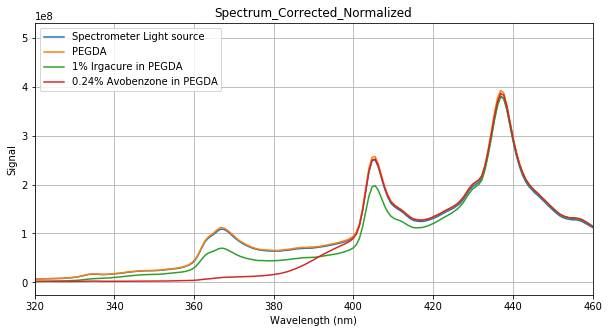

In [5]:
start_index = 305
end_index = 330

print(IRGA_PEGDA_wavelength[start_index])
print(IRGA_PEGDA_wavelength[end_index])


temp_irga = (IRGA_PEGDA_signal_corrected[start_index:end_index])/(PEGDA_signal_corrected[start_index:end_index])
gamma_irga = temp_irga.mean()
print(gamma_irga)

temp_avobenzone = (Avobenzone_signal_corrected[start_index:end_index])/(PEGDA_signal_corrected[start_index:end_index])
gamma_avobenzone = temp_avobenzone.mean()
print(gamma_avobenzone)

IRGA_PEGDA_signal_corrected_normalized= IRGA_PEGDA_signal_corrected/gamma_irga
Avobenzone_signal_corrected_normalized = Avobenzone_signal_corrected/gamma_avobenzone

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(light_source_wavelength, light_source_signal_corrected , label = 'Spectrometer Light source') # we don't care
ax.plot(PEGDA_wavelength, PEGDA_signal_corrected, label = 'PEGDA') # this is the baseline
ax.plot(IRGA_PEGDA_wavelength, IRGA_PEGDA_signal_corrected_normalized, label = '1% Irgacure in PEGDA')
ax.plot(Avobenzone_wavelength, Avobenzone_signal_corrected_normalized, label = '0.24% Avobenzone in PEGDA')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Signal')
ax.set_title("Spectrum_Corrected_Normalized")
ax.set_xlim([320, 460])
#ax.set_ylim([1e8, 3.25e8])
ax.legend()
ax.grid()
os.chdir('C:/Users/Mawla/Desktop/Winter 2020/Lab Stuff_Winter 2020/Paper Plan/200120_old_spectrometer/200120_Fig')
plt.savefig("Spectrum_200120_correted_normalized.png")

In [5]:
dir(temp_irga)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_prepare__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__class__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__or__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdivmod__',
 '__

C:\Users\Mawla\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\Mawla\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until
C:\Users\Mawla\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: RuntimeWarning: divide by zero encountered in true_divide
  after removing the cwd from sys.path.


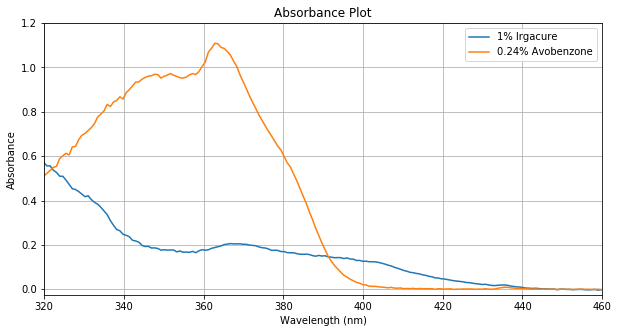

In [8]:
# Absorbance plot:

absorbance_data_IRGA = -np.log10(IRGA_PEGDA_signal_corrected_normalized/PEGDA_signal_corrected)
absorbance_data_Avobenzone = -np.log10(Avobenzone_signal_corrected_normalized/PEGDA_signal_corrected)


#print(absorbance_data_IRGA)
#print(absorbance_data_Avobenzone)

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(IRGA_PEGDA_wavelength, absorbance_data_IRGA, label = '1% Irgacure')
ax.plot(Avobenzone_wavelength, absorbance_data_Avobenzone, label = '0.24% Avobenzone')


ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Absorbance')
ax.set_title("Absorbance Plot")
ax.set_xlim([320, 460])
ax.set_ylim([-.025, 1.2])
ax.legend()
ax.grid()
plt.savefig("Absorbance_200120.png")

In [16]:
print(10**(-.12))
print(10**(-.2))
print(10**(-.3))
print(10**(-.8))
print(10**(-1.1))

0.7585775750291838
0.6309573444801932
0.5011872336272722
0.15848931924611134
0.07943282347242814
